# 02 — Semivariograma do resíduo

**Pergunta:** o resíduo de um ponto prevê o do vizinho?

O semivariograma responde medindo, para cada distância *h*, o quanto os resíduos de pares de pontos diferem:

γ(h) = ½ · média de (r_i − r_j)²  sobre os pares a distância h

- γ baixo = pontos parecidos. γ alto = pontos diferentes.
- Se γ **cresce com h**, o resíduo tem estrutura espacial.
- O valor de γ em h ≈ 0 é o **nugget**: ruído sem estrutura (erro de medida incluído).

## Passo 1 — Preparar (igual ao notebook 01)

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))

from src.processing.fusion import load_sandwell, build_observations

sandwell = load_sandwell()
obs, info = build_observations("ok", "add", sandwell)
print(obs["source"].value_counts())

source
marine    64565
CPRM       2816
RGFB        107
Name: count, dtype: int64


## Passo 2 — Coordenadas em km

Distância em graus não serve (1° de longitude ≠ 1° de latitude). Convertemos para km com uma aproximação plana, boa nesta área.

In [2]:
lat0 = obs["lat"].mean()
obs["x"] = obs["lon"] * 111.32 * np.cos(np.radians(lat0))
obs["y"] = obs["lat"] * 111.0

mar = obs[obs["source"] == "marine"].sample(4000, random_state=0)   # amostra: são 64 mil pontos
terra = obs[obs["source"] == "CPRM"]
print("mar:", len(mar), " terra:", len(terra))

mar: 4000  terra: 2816


## Passo 3 — A função do semivariograma

Passos dentro dela:
1. `query_pairs` acha todos os pares de pontos a menos de `bins[-1]` km.
2. Para cada par: distância `d` e `g = ½ (r_i − r_j)²`.
3. Agrupa os pares por faixa de distância e tira a média de `g` em cada faixa.

In [4]:
def semivariograma(x, y, r, bins):
    pontos = np.column_stack([x, y])
    pares = cKDTree(pontos).query_pairs(r=bins[-1], output_type="ndarray")
    i, j = pares[:, 0], pares[:, 1]
    d = np.hypot(x[i] - x[j], y[i] - y[j])
    g = 0.5 * (r[i] - r[j]) ** 2
    faixa = np.digitize(d, bins) - 1
    nb = len(bins) - 1
    gamma = np.full(nb, np.nan)
    n = np.zeros(nb, dtype=int)
    for b in range(nb):
        sel = faixa == b
        n[b] = sel.sum()
        if n[b] > 0:
            gamma[b] = g[sel].mean()
    centros = 0.5 * (bins[:-1] + bins[1:])
    return centros, gamma, n

## Passo 4 — Calcular para mar e terra

In [5]:
bins_mar = np.arange(0, 201, 10)     # km
bins_terra = np.arange(0, 101, 5)    # km

h_m, g_m, n_m = semivariograma(mar["x"].values, mar["y"].values, mar["r"].values, bins_mar)
h_t, g_t, n_t = semivariograma(terra["x"].values, terra["y"].values, terra["r"].values, bins_terra)

print("pares por faixa (mar): ", n_m)
print("pares por faixa (terra):", n_t)

pares por faixa (mar):  [49386 46542 47468 48729 53155 56037 58748 63533 59021 65944 61928 61514
 60087 61003 64796 65691 65764 66543 65622 69566]
pares por faixa (terra): [21183 34258 39009 38578 37679 40219 41354 44357 44200 43423 41668 39662
 38818 41994 42752 42776 40292 39471 39462 40013]


## Passo 5 — Gráfico

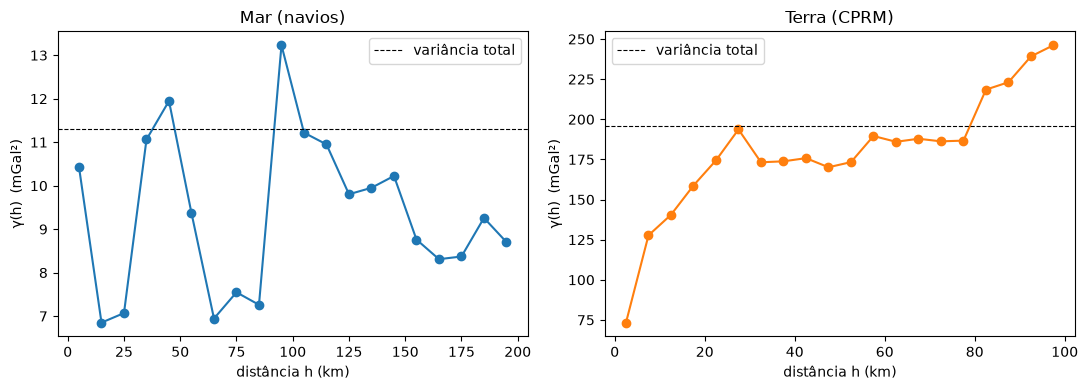

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(11, 4))

axs[0].plot(h_m, g_m, "o-", color="tab:blue")
axs[0].axhline(mar["r"].var(), color="k", ls="--", lw=0.8, label="variância total")
axs[0].set_title("Mar (navios)")

axs[1].plot(h_t, g_t, "o-", color="tab:orange")
axs[1].axhline(terra["r"].var(), color="k", ls="--", lw=0.8, label="variância total")
axs[1].set_title("Terra (CPRM)")

for ax in axs:
    ax.set_xlabel("distância h (km)")
    ax.set_ylabel("γ(h)  (mGal²)")
    ax.legend()
plt.tight_layout()
plt.show()

**Para observar:**

- Onde a curva começa (h ≈ 0)? Esse é o nugget.
- A curva sobe e depois achata na linha tracejada? A distância em que ela achata é o **alcance**: além dela, o resíduo de um ponto não diz mais nada sobre o vizinho.
- Mar e terra têm nuggets e alcances parecidos?

**Pergunta para você:** o nugget de terra é grande ou pequeno em comparação com o σ = 2,4 mGal do log de 23/09? (σ² = 5,8 mGal²; o nugget está em mGal², então compare com esse número, e não com 2,4.)